# Prueba técnica – Equipo Canales Digitales  
## Desarrollo completo en Python

Este notebook resuelve paso a paso los 7 puntos de la prueba técnica a partir del archivo `Dataset_prueba.zip`.

### Objetivos
1. Identificar los productos/categorías más vendidos por **volumen** e **ingresos**.
2. Detectar el principal **dolor del cliente** y los productos/categorías asociados.
3. Diseñar y ejecutar una **segmentación de clientes** orientada a marketing.
4. Proponer una **arquitectura de recomendación en tiempo real**.
5. Recomendar la mejor **ciudad/zona** para una tienda física insignia.
6. Construir una **base de conocimiento** para un agente de IA.
7. Definir **3 system prompts** hiperpersonalizados.

### Supuestos clave
- **Volumen vendido** = número de filas en `order_items_dataset` (el dataset no trae cantidad explícita por línea).
- **Ingresos de producto** = suma de `price` de los ítems.  
  No incluyo `freight_value` como ingreso del producto.
- Para métricas de ventas y valor de cliente trabajo principalmente con pedidos **`delivered`**, porque representan ventas efectivamente completadas.
- Dado que no hay nombres comerciales legibles por SKU, el análisis de negocio se apoya sobre todo en **categorías**.
- El “dolor” del cliente se aproxima con 3 señales: **reseña baja**, **entrega tardía** y **estado problemático** (`canceled` o `unavailable`).


In [1]:
from pathlib import Path
import zipfile
import json
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")


## 0. Carga y entendimiento del dataset

In [2]:
BASE_DIR = Path.cwd()
ZIP_PATH = BASE_DIR / "Dataset_prueba.zip"
DATASET_DIR = BASE_DIR / "Dataset_prueba"
EXTRACT_DIR = BASE_DIR / "dataset_prueba_extracted"

if DATASET_DIR.exists():
    SOURCE_DIR = DATASET_DIR
elif ZIP_PATH.exists():
    EXTRACT_DIR.mkdir(exist_ok=True)
    with zipfile.ZipFile(ZIP_PATH, "r") as zf:
        zf.extractall(EXTRACT_DIR)
    SOURCE_DIR = EXTRACT_DIR
else:
    raise FileNotFoundError(
        "No encontré ni `Dataset_prueba/` ni `Dataset_prueba.zip` en el directorio actual. "
        "Verifica la ruta del notebook o ajusta `BASE_DIR`."
    )

csv_files = sorted([p.name for p in SOURCE_DIR.glob("*.csv")])
if not csv_files:
    raise FileNotFoundError(f"No encontré archivos CSV dentro de {SOURCE_DIR}")

print(f"Usando datasets desde: {SOURCE_DIR}")
csv_files

Usando datasets desde: /home/dsrojo10/Prueba_Pr/Dataset_prueba


['customers_dataset.csv',
 'geolocation_dataset.csv',
 'order_items_dataset.csv',
 'order_payments_dataset.csv',
 'order_reviews_dataset.csv',
 'orders_dataset.csv',
 'product_category_name_translation.csv',
 'products_dataset.csv',
 'sellers_dataset.csv']

In [3]:
orders = pd.read_csv(SOURCE_DIR / "orders_dataset.csv")
items = pd.read_csv(SOURCE_DIR / "order_items_dataset.csv")
products = pd.read_csv(SOURCE_DIR / "products_dataset.csv")
customers = pd.read_csv(SOURCE_DIR / "customers_dataset.csv")
reviews = pd.read_csv(SOURCE_DIR / "order_reviews_dataset.csv")
payments = pd.read_csv(SOURCE_DIR / "order_payments_dataset.csv")
sellers = pd.read_csv(SOURCE_DIR / "sellers_dataset.csv")
geoloc = pd.read_csv(SOURCE_DIR / "geolocation_dataset.csv")
translation = pd.read_csv(SOURCE_DIR / "product_category_name_translation.csv")

overview = pd.DataFrame({
    "tabla": ["orders", "items", "products", "customers", "reviews", "payments", "sellers", "geoloc", "translation"],
    "filas": [len(orders), len(items), len(products), len(customers), len(reviews), len(payments), len(sellers), len(geoloc), len(translation)],
    "columnas": [orders.shape[1], items.shape[1], products.shape[1], customers.shape[1], reviews.shape[1], payments.shape[1], sellers.shape[1], geoloc.shape[1], translation.shape[1]],
})
overview

,tabla,filas,columnas
0,orders,99441,8
1,items,112650,7
2,products,32951,9
3,customers,99441,5
4,reviews,99224,7
5,payments,103886,5
6,sellers,3095,4
7,geoloc,1000163,5
8,translation,71,2


In [4]:
for df, cols in [
    (orders, [
        "order_purchase_timestamp", "order_approved_at",
        "order_delivered_carrier_date", "order_delivered_customer_date",
        "order_estimated_delivery_date"
    ]),
    (items, ["shipping_limit_date"]),
    (reviews, ["review_creation_date", "review_answer_timestamp"]),
]:
    for c in cols:
        df[c] = pd.to_datetime(df[c], errors="coerce")

products = products.merge(translation, on="product_category_name", how="left")
products["category_en"] = (
    products["product_category_name_english"]
    .fillna(products["product_category_name"])
    .fillna("unknown")
)

orders["order_status"].value_counts().to_frame("n_pedidos")


,n_pedidos
order_status,
delivered,96478
shipped,1107
canceled,625
unavailable,609
invoiced,314
processing,301
created,5
approved,2


### Construcción de tablas analíticas

Voy a crear dos vistas principales:

- **`order_level`**: una fila por pedido, útil para experiencia de cliente y segmentación.
- **`master`**: una fila por ítem, útil para ventas por producto/categoría.


In [5]:
order_value = (
    items.groupby("order_id", as_index=False)
         .agg(
             order_revenue=("price", "sum"),
             freight_total=("freight_value", "sum"),
             n_items=("order_item_id", "count")
         )
)

order_level = (
    orders.merge(order_value, on="order_id", how="left")
          .merge(reviews[["order_id", "review_score"]], on="order_id", how="left")
          .merge(customers, on="customer_id", how="left")
)

order_level["order_revenue"] = order_level["order_revenue"].fillna(0)
order_level["delay_days_vs_est"] = (
    order_level["order_delivered_customer_date"] - order_level["order_estimated_delivery_date"]
).dt.days
order_level["late_delivery"] = order_level["delay_days_vs_est"] > 0
order_level["problem_status"] = order_level["order_status"].isin(["canceled", "unavailable"])
order_level["low_review"] = order_level["review_score"].fillna(5) <= 2
order_level["bad_experience"] = (
    order_level[["late_delivery", "problem_status", "low_review"]]
    .fillna(False)
    .any(axis=1)
)

master = (
    items.merge(products[["product_id", "category_en"]], on="product_id", how="left")
         .merge(orders, on="order_id", how="left")
         .merge(customers, on="customer_id", how="left")
         .merge(reviews[["order_id", "review_score"]], on="order_id", how="left")
)

master["revenue"] = master["price"]
master["delay_days_vs_est"] = (
    master["order_delivered_customer_date"] - master["order_estimated_delivery_date"]
).dt.days
master["late_delivery"] = master["delay_days_vs_est"] > 0
master["problem_status"] = master["order_status"].isin(["canceled", "unavailable"])
master["low_review"] = master["review_score"].fillna(5) <= 2
master["bad_experience"] = (
    master[["late_delivery", "problem_status", "low_review"]]
    .fillna(False)
    .any(axis=1)
)

orders_delivered = order_level[order_level["order_status"] == "delivered"].copy()
master_delivered = master[master["order_status"] == "delivered"].copy()

print("order_level:", order_level.shape)
print("master:", master.shape)
print("orders_delivered:", orders_delivered.shape)
print("master_delivered:", master_delivered.shape)


order_level: (99992, 21)
master: (113314, 26)
orders_delivered: (97007, 21)
master_delivered: (110840, 26)


## Punto 1 — Productos/categorías más vendidos por volumen e ingresos

### Pregunta
¿Cuáles son los 5 productos (o categorías de productos) más vendidos en términos de
volumen y cuáles en términos de ingresos totales?

### Método
1. Se filtraron pedidos con estado `delivered` para representar ventas efectivamente completadas.  
2. Se construyó una tabla a nivel ítem (`master_delivered`), uniendo órdenes, ítems y categorías.  
3. Se calcularon dos métricas por categoría y por producto:
   - **Volumen**: conteo de líneas de ítem (`order_item_id`).
   - **Ingresos**: suma de `price`.
4. Se ordenaron resultados y se extrajeron los **Top 5** por cada métrica.

### Hallazgo
- En **volumen**, destaca `bed_bath_table` como principal categoría de rotación.
- En **ingresos**, lidera `health_beauty`.
- `watches_gifts` aparece con alto peso en ingresos pese a menor volumen relativo, señal de **ticket promedio más alto**.

### Implicación de negocio
No conviene gestionar todas las categorías con la misma lógica:
- Categorías de **alta rotación** (ej. `bed_bath_table`) → estrategia de disponibilidad, pricing competitivo y reposición rápida.
- Categorías de **alto valor** (ej. `health_beauty`, `watches_gifts`) → estrategia de margen, bundles, upsell y campañas segmentadas.
- Recomendación táctica: definir un portafolio dual “**traffic drivers**” vs “**profit drivers**”.

### Supuestos
- El dataset no incluye cantidad explícita por línea; por eso se aproxima volumen con conteo de registros en `order_items_dataset`.
- El ingreso de producto se modela como suma de `price` (sin incluir `freight_value`).
- Se prioriza `delivered` para evitar sesgo por pedidos cancelados/no completados.
- El análisis de negocio se centra en categorías porque no hay naming comercial legible por SKU.

In [6]:
category_sales = (
    master_delivered.groupby("category_en", as_index=False)
                   .agg(
                       volume=("order_item_id", "count"),
                       revenue=("revenue", "sum"),
                       avg_price=("price", "mean")
                   )
)

top5_volume = category_sales.sort_values(["volume", "revenue"], ascending=False).head(5)
top5_revenue = category_sales.sort_values(["revenue", "volume"], ascending=False).head(5)

print("Top 5 categorías por volumen")
display(top5_volume)

print("Top 5 categorías por ingresos")
display(top5_revenue)


Top 5 categorías por volumen


,category_en,volume,revenue,avg_price
7,bed_bath_table,11107,"1,037,177.69",93.38
43,health_beauty,9519,"1,237,439.95",130.00
67,sports_leisure,8489,"960,189.09",113.11
39,furniture_decor,8239,"718,344.78",87.19
15,computers_accessories,7708,"896,243.28",116.27


Top 5 categorías por ingresos


,category_en,volume,revenue,avg_price
43,health_beauty,9519,"1,237,439.95",130.00
73,watches_gifts,5869,"1,167,246.63",198.88
7,bed_bath_table,11107,"1,037,177.69",93.38
67,sports_leisure,8489,"960,189.09",113.11
15,computers_accessories,7708,"896,243.28",116.27


In [7]:
product_sales = (
    master_delivered.groupby("product_id", as_index=False)
                   .agg(
                       volume=("order_item_id", "count"),
                       revenue=("revenue", "sum")
                   )
)

top5_products_volume = product_sales.sort_values(["volume", "revenue"], ascending=False).head(5)
top5_products_revenue = product_sales.sort_values(["revenue", "volume"], ascending=False).head(5)

print("Top 5 product_id por volumen")
display(top5_products_volume)

print("Top 5 product_id por ingresos")
display(top5_products_revenue)


Top 5 product_id por volumen


,product_id,volume,revenue
21617,aca2eb7d00ea1a7b8ebd4e68314663af,520,"37,104.30"
8429,422879e10f46682990de24d770e7f83d,487,"26,734.02"
19290,99a4788cb24856965c36a24e339b6058,480,"42,316.36"
6926,368c6c730842d78016ad823897a372db,391,"21,230.50"
7206,389d119b48cf3043d311335e499d9c6b,390,"21,336.79"


Top 5 product_id por ingresos


,product_id,volume,revenue
23546,bb50f2e236e5eea0100680137654686c,195,"63,885.00"
13749,6cdd53843498f92890544667809f1595,153,"53,652.30"
26997,d6160fb7873f184099d9bc95e30376af,33,"45,949.35"
26436,d1c427060a0f73f6b889a5c7c61f2ac4,332,"45,620.56"
19290,99a4788cb24856965c36a24e339b6058,480,"42,316.36"


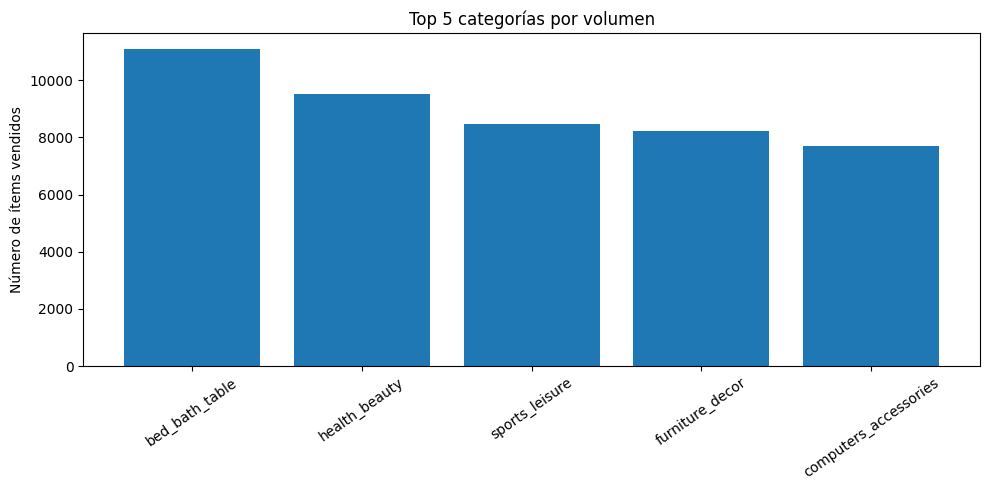

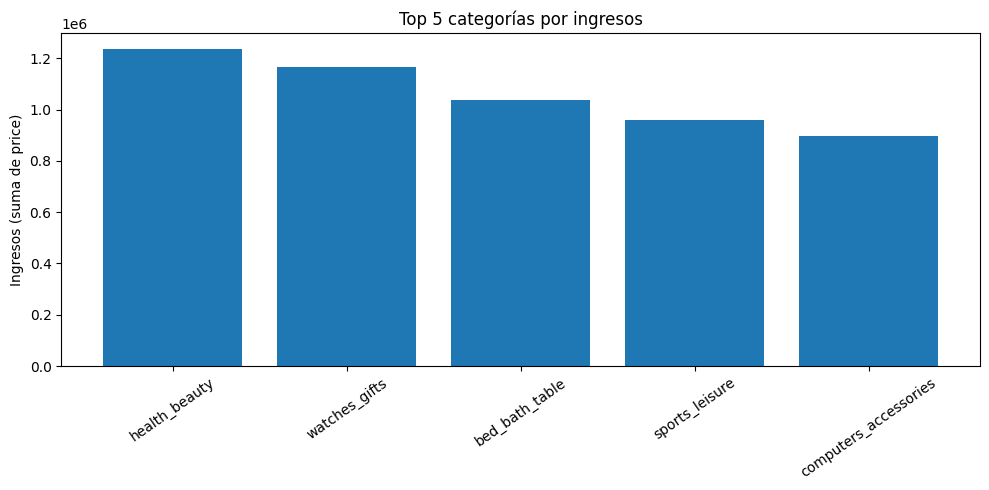

In [8]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(top5_volume["category_en"], top5_volume["volume"])
ax.set_title("Top 5 categorías por volumen")
ax.set_ylabel("Número de ítems vendidos")
ax.tick_params(axis="x", rotation=35)
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(top5_revenue["category_en"], top5_revenue["revenue"])
ax.set_title("Top 5 categorías por ingresos")
ax.set_ylabel("Ingresos (suma de price)")
ax.tick_params(axis="x", rotation=35)
plt.tight_layout()
plt.show()


## Punto 2 — Mayor dolor del cliente y categorías relacionadas

### Pregunta
¿Cuál es el mayor dolor de nuestros clientes y qué productos o categorías están
directamente relacionados con estas malas experiencias?

### Método
1. Se definió una señal compuesta de fricción (`bad_experience`) a nivel pedido/ítem con tres componentes:
   - `late_delivery`: entrega posterior a la fecha estimada.
   - `low_review`: reseña baja (`review_score <= 2`).
   - `problem_status`: pedidos `canceled` o `unavailable`.
2. Se calculó la incidencia global de cada componente (`pain_summary`).
3. Se analizó la relación entre atraso y satisfacción usando buckets de atraso (`delay_bucket`) y métricas de review.
4. Se estimó la fricción por categoría (`pain_by_category`) y se filtraron categorías con volumen relevante (`volume >= 500`) para evitar conclusiones por baja muestra.

### Hallazgo
- El dolor dominante es **logístico**: el atraso de entrega es la señal más vinculada con caída de satisfacción.
- A mayor atraso, menor review promedio y mayor tasa de reseñas bajas.
- Las categorías con mayor concentración de mala experiencia (con masa crítica) incluyen:
  - `office_furniture`
  - `furniture_decor`
  - `bed_bath_table`
  - `computers_accessories`
  - `telephony`

### Implicación de negocio
- La principal palanca de NPS/reputación no está solo en pricing o surtido, sino en **cumplimiento logístico**.
- Conviene priorizar un plan por categorías críticas:
  - mejora de SLA de entrega,
  - control de promesa de fecha estimada,
  - seguimiento preventivo post-compra.
- Recomendación táctica: crear un **“watchlist operativo”** por categoría con alertas de atraso y acciones de recuperación temprana para clientes en riesgo.

### Supuestos
- Se usa `order_estimated_delivery_date` como referencia de promesa al cliente.
- `review_score <= 2` se considera proxy de insatisfacción severa.
- La señal `bad_experience` se modela como OR lógico de las tres fricciones.
- Para análisis de categorías se prioriza robustez estadística mediante umbral de volumen (`>= 500`).

In [9]:
pain_summary = pd.DataFrame({
    "metric": [
        "Tasa de entregas tardías (delivered)",
        "Tasa de reseñas bajas 1-2 (delivered)",
        "Tasa de estados problemáticos (global)"
    ],
    "value": [
        orders_delivered["late_delivery"].mean(),
        orders_delivered["low_review"].mean(),
        order_level["problem_status"].mean()
    ]
})
pain_summary["value_pct"] = (pain_summary["value"] * 100).round(2).astype(str) + "%"
pain_summary[["metric", "value_pct"]]


,metric,value_pct
0,Tasa de entregas tardías (delivered),6.76%
1,Tasa de reseñas bajas 1-2 (delivered),12.73%
2,Tasa de estados problemáticos (global),1.24%


In [10]:
orders_delivered["delay_bucket"] = pd.cut(
    orders_delivered["delay_days_vs_est"].fillna(-999),
    bins=[-1000, -1, 0, 3, 7, 9999],
    labels=["Early", "On time", "1-3 days late", "4-7 days late", "8+ days late"]
)

delay_vs_review = (
    orders_delivered.groupby("delay_bucket", observed=True)
                   .agg(
                       orders=("order_id", "nunique"),
                       avg_review=("review_score", "mean"),
                       low_review_rate=("low_review", "mean")
                   )
                   .reset_index()
)

delay_vs_review["low_review_rate"] = delay_vs_review["low_review_rate"] * 100
delay_vs_review


,delay_bucket,orders,avg_review,low_review_rate
0,Early,88652,4.29,9.18
1,On time,1292,4.03,12.28
2,1-3 days late,1870,3.29,31.86
3,4-7 days late,1802,2.10,65.64
4,8+ days late,2862,1.70,76.96


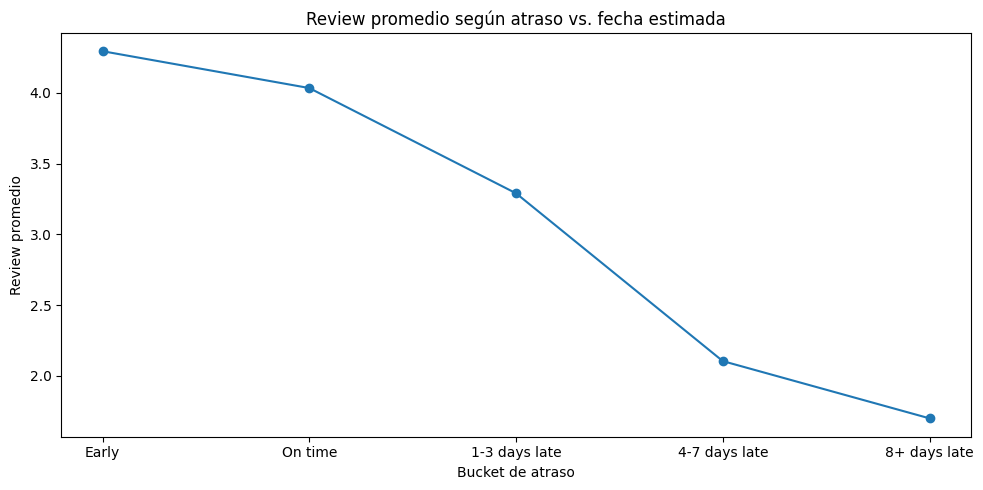

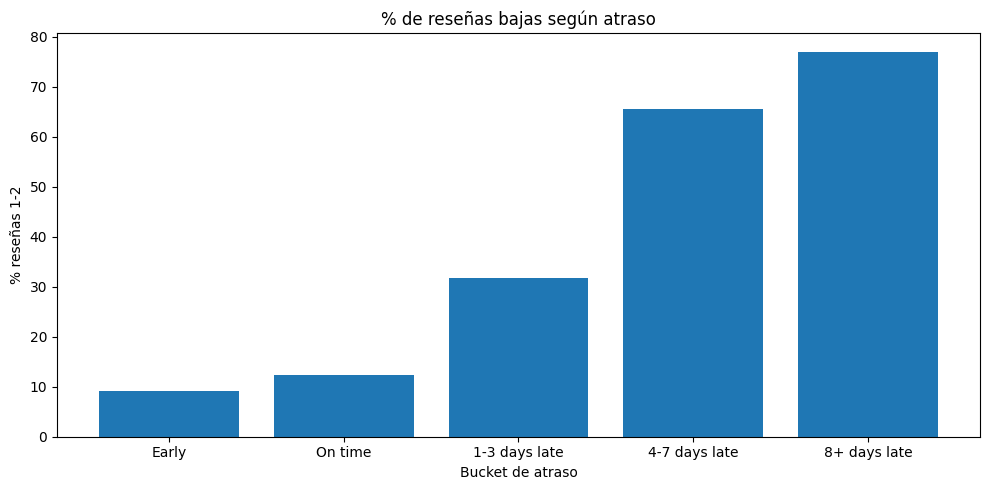

In [11]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(delay_vs_review["delay_bucket"].astype(str), delay_vs_review["avg_review"], marker="o")
ax.set_title("Review promedio según atraso vs. fecha estimada")
ax.set_ylabel("Review promedio")
ax.set_xlabel("Bucket de atraso")
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(delay_vs_review["delay_bucket"].astype(str), delay_vs_review["low_review_rate"])
ax.set_title("% de reseñas bajas según atraso")
ax.set_ylabel("% reseñas 1-2")
ax.set_xlabel("Bucket de atraso")
plt.tight_layout()
plt.show()


In [12]:
pain_by_category = (
    master.groupby("category_en", as_index=False)
          .agg(
              volume=("order_item_id", "count"),
              revenue=("revenue", "sum"),
              late_delivery_rate=("late_delivery", "mean"),
              low_review_rate=("low_review", "mean"),
              problem_status_rate=("problem_status", "mean"),
              bad_exp_rate=("bad_experience", "mean"),
              avg_review=("review_score", "mean")
          )
)

pain_by_category_filtered = (
    pain_by_category[pain_by_category["volume"] >= 500]
    .sort_values(["bad_exp_rate", "volume"], ascending=[False, False])
)

pain_by_category_filtered.head(10)


,category_en,volume,revenue,late_delivery_rate,low_review_rate,problem_status_rate,bad_exp_rate,avg_review
57,office_furniture,1701,"275,224.49",0.08,0.26,0.00,0.29,3.49
72,unknown,1612,"180,277.24",0.07,0.22,0.01,0.24,3.84
39,furniture_decor,8415,"736,282.47",0.07,0.19,0.00,0.22,3.90
7,bed_bath_table,11270,"1,050,936.61",0.07,0.19,0.00,0.21,3.90
15,computers_accessories,7894,"919,640.54",0.06,0.19,0.01,0.21,3.93
40,furniture_living_room,507,"69,427.26",0.07,0.18,0.00,0.21,3.90
48,home_construction,605,"83,207.97",0.06,0.18,0.00,0.20,3.94
70,telephony,4550,"323,839.40",0.07,0.17,0.00,0.20,3.95
6,baby,3073,"412,117.47",0.07,0.17,0.01,0.19,4.01
73,watches_gifts,6001,"1,206,075.33",0.07,0.16,0.00,0.19,4.02


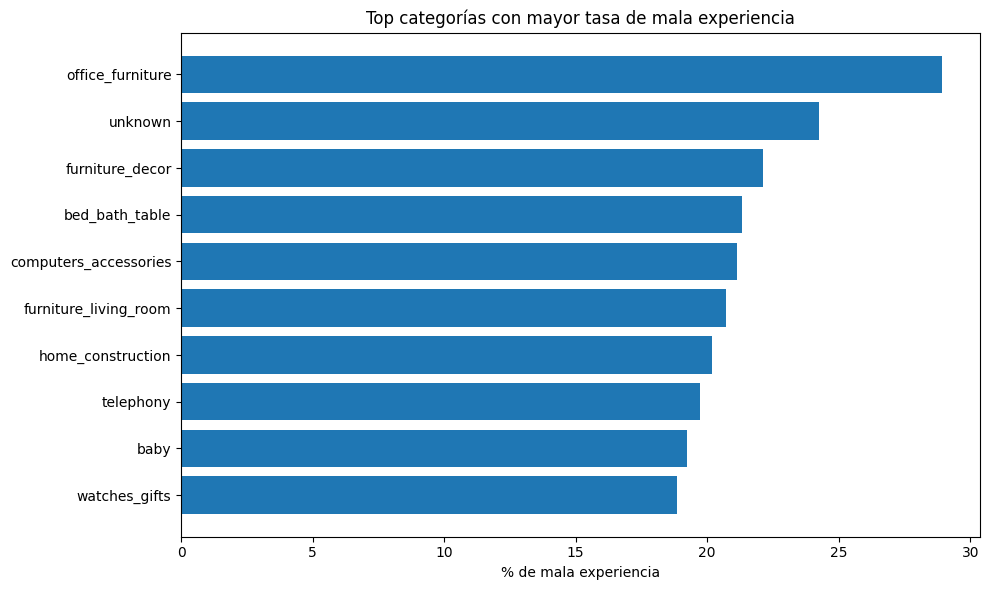

In [13]:
fig, ax = plt.subplots(figsize=(10, 6))
plot_df = pain_by_category_filtered.head(10).sort_values("bad_exp_rate")
ax.barh(plot_df["category_en"], plot_df["bad_exp_rate"] * 100)
ax.set_title("Top categorías con mayor tasa de mala experiencia")
ax.set_xlabel("% de mala experiencia")
plt.tight_layout()
plt.show()


## Punto 3 — Segmentación de clientes (RFM accionable para marketing)

### Pregunta
Diseña y ejecuta una segmentación de clientes que permita a nuestro equipo de marketing
distinguir claramente a los "clientes fieles" de los compradores esporádicos o en riesgo de
abandono.

### Método
1. Se tomó la base de pedidos `delivered` y se consolidó a nivel cliente (`customer_unique_id`).
2. Se construyeron variables RFM:
   - **Recency**: días desde la última compra.
   - **Frequency**: número de pedidos.
   - **Monetary**: gasto total.
3. Se agregaron variables útiles de activación comercial:
   - `avg_ticket` (ticket promedio),
   - `total_items` (ítems totales).
4. Se definieron segmentos con reglas de negocio (no clustering):
   - **VIP**: `monetary >= p95` y `recency <= 365`
   - **Fiel**: `frequency >= 2` y `recency <= 365`
   - **En riesgo**: `recency > 365`
   - **Esporádico**: resto de clientes
5. Se perfilaron segmentos por tamaño, valor y comportamiento de compra.

### Hallazgo
- La base está fuertemente concentrada en clientes de **una sola compra**.
- El grupo **recurrente (2+ compras)** es menor, pero concentra mejor desempeño de valor.
- La segmentación separa claramente perfiles de:
  - alto valor (**VIP**),
  - recurrencia activa (**Fiel**),
  - baja vinculación (**Esporádico**),
  - abandono potencial (**En riesgo**).

### Implicación de negocio
- El principal reto no es solo adquisición, sino **conversión a segunda compra**.
- Plan recomendado por segmento:
  - **Esporádico** → onboarding, best sellers y incentivo de segunda compra.
  - **Fiel** → cross-sell, reposición y programas de fidelización.
  - **VIP** → beneficios premium, bundles de alto margen, atención preferencial.
  - **En riesgo** → campañas de reactivación y recuperación de confianza.
- Esta segmentación habilita personalización directa en CRM, paid media y recomendador.

### Supuestos
- Se usa una foto temporal única (`snapshot_date`) para calcular recency.
- Se trabaja con `delivered` para representar valor efectivamente realizado.
- `customer_unique_id` representa la entidad cliente para consolidación histórica.
- Se priorizan reglas interpretables para negocio sobre modelos no supervisados, por necesidad de ejecución táctica inmediata.

In [14]:
cust_tx = orders_delivered.merge(
    order_value[["order_id", "order_revenue", "n_items"]],
    on="order_id",
    how="left",
    suffixes=("", "_dup")
)

# Si el merge deja columnas duplicadas por venir desde order_level, me quedo con la principal
for col in ["order_revenue", "n_items"]:
    dup = f"{col}_dup"
    if dup in cust_tx.columns:
        cust_tx[col] = cust_tx[col].fillna(cust_tx[dup])
        cust_tx = cust_tx.drop(columns=[dup])

snapshot_date = cust_tx["order_purchase_timestamp"].max() + pd.Timedelta(days=1)

rfm = (
    cust_tx.groupby("customer_unique_id", as_index=False)
           .agg(
               recency=("order_purchase_timestamp", lambda s: (snapshot_date - s.max()).days),
               frequency=("order_id", "nunique"),
               monetary=("order_revenue", "sum"),
               avg_ticket=("order_revenue", "mean"),
               total_items=("n_items", "sum")
           )
)

p95_monetary = rfm["monetary"].quantile(0.95)

rfm["segment"] = np.select(
    [
        (rfm["monetary"] >= p95_monetary) & (rfm["recency"] <= 365),
        (rfm["frequency"] >= 2) & (rfm["recency"] <= 365),
        (rfm["recency"] > 365)
    ],
    [
        "VIP",
        "Fiel",
        "En riesgo"
    ],
    default="Esporádico"
)

rfm.head()


,customer_unique_id,recency,frequency,monetary,avg_ticket,total_items,segment
0,0000366f3b9a7992bf8c76cfdf3221e2,112,1,129.90,129.90,1.00,Esporádico
1,0000b849f77a49e4a4ce2b2a4ca5be3f,115,1,18.90,18.90,1.00,Esporádico
2,0000f46a3911fa3c0805444483337064,537,1,69.00,69.00,1.00,En riesgo
3,0000f6ccb0745a6a4b88665a16c9f078,321,1,25.99,25.99,1.00,Esporádico
4,0004aac84e0df4da2b147fca70cf8255,288,1,180.00,180.00,1.00,Esporádico


In [15]:
segment_counts = rfm["segment"].value_counts().rename_axis("segment").reset_index(name="clientes")
segment_profile = (
    rfm.groupby("segment")
       .agg(
           clientes=("segment", "size"),
           recency_promedio=("recency", "mean"),
           frequency_promedio=("frequency", "mean"),
           gasto_promedio=("monetary", "mean"),
           ticket_promedio=("avg_ticket", "mean"),
           items_promedio=("total_items", "mean")
       )
       .sort_values("clientes", ascending=False)
)

display(segment_counts)
display(segment_profile.round(2))


,segment,clientes
0,Esporádico,67023
1,En riesgo,20738
2,VIP,3667
3,Fiel,1930


,clientes,recency_promedio,frequency_promedio,gasto_promedio,ticket_promedio,items_promedio
segment,,,,,,
Esporádico,67023,173.62,1.00,104.22,104.17,1.13
En riesgo,20738,463.36,1.03,140.29,136.49,1.17
VIP,3667,174.38,1.14,825.69,779.35,1.68
Fiel,1930,170.18,2.07,185.34,87.14,2.51


In [16]:
one_time_share = (rfm["frequency"] == 1).mean() * 100
repeat_share = (rfm["frequency"] >= 2).mean() * 100

print(f"% clientes de una sola compra: {one_time_share:.2f}%")
print(f"% clientes recurrentes (2+ compras): {repeat_share:.2f}%")


% clientes de una sola compra: 97.00%
% clientes recurrentes (2+ compras): 3.00%


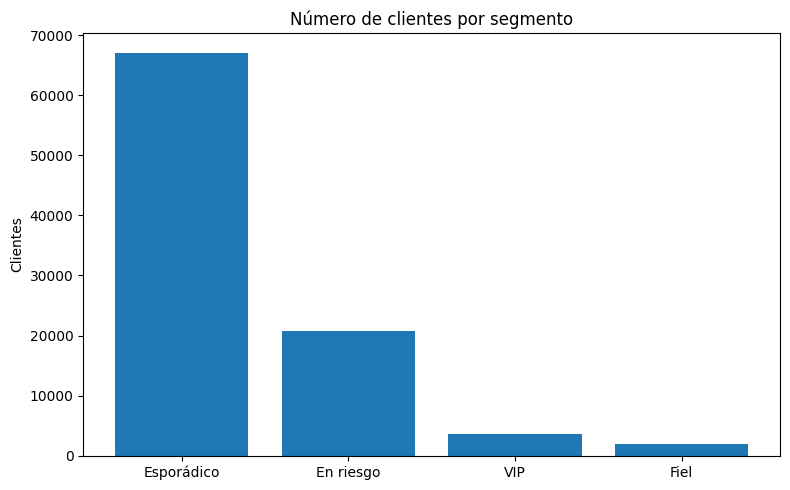

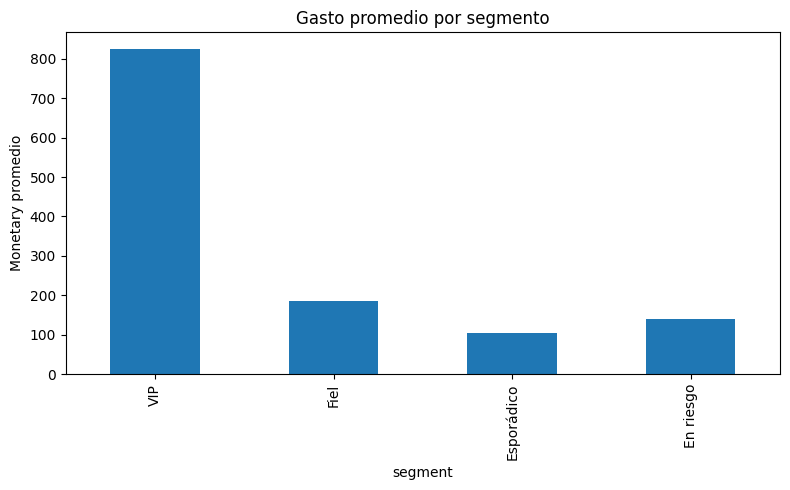

In [17]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(segment_counts["segment"], segment_counts["clientes"])
ax.set_title("Número de clientes por segmento")
ax.set_ylabel("Clientes")
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(8, 5))
segment_profile.loc[["VIP", "Fiel", "Esporádico", "En riesgo"], "gasto_promedio"].plot(kind="bar", ax=ax)
ax.set_title("Gasto promedio por segmento")
ax.set_ylabel("Monetary promedio")
plt.tight_layout()
plt.show()


## Punto 4 — Arquitectura y flujo lógico del recomendador en tiempo real

### Pregunta
Diseña una arquitectura y un flujo lógico de un modelo de recomendación automática de
productos en tiempo real cuando un cliente visita nuestra página web, basándose en su perfil
de cliente (obtenido en el punto anterior) y su historial de compras.

### Método
1. Se propuso un esquema **híbrido** con tres motores de candidatos:
   - **Best sellers por segmento** (popularidad contextual),
   - **Content-based** (similitud con historial del cliente),
   - **Collaborative filtering** (comportamiento de clientes similares).
2. Se definió un flujo online:
   - identificación de cliente/sesión,
   - recuperación de features (segmento RFM, categorías favoritas, recencia, ticket),
   - generación de candidatos,
   - aplicación de reglas de negocio,
   - ranking final y serving de Top-N.
3. Se incorporaron reglas de negocio para control operativo:
   - excluir productos sin stock,
   - modular recomendaciones según riesgo de churn o mala experiencia previa,
   - priorizar premium para VIP.
4. Se estableció una fórmula de scoring ponderada (`recommendation_score`) para combinar señales históricas, contextuales y de negocio.

### Hallazgo
- Un enfoque híbrido es el más robusto para este caso porque evita depender de una sola señal.
- Mejora el **cold start** frente a un colaborativo puro.
- Permite alinear recomendación con objetivos comerciales (margen, rotación, recuperación de confianza).

### Implicación de negocio
- El recomendador pasa de ser “solo tecnológico” a una palanca directa de:
  - **conversión** (CTR, add-to-cart, CVR),
  - **ticket promedio** (upsell/cross-sell),
  - **retención** (experiencia personalizada por segmento).
- Recomendación táctica: lanzar un **MVP** con A/B testing y metas claras por segmento (VIP, Fiel, Esporádico, En riesgo).
- Gobernanza recomendada: monitoreo de precisión, sesgo por popularidad y impacto en categorías estratégicas.

### Supuestos
- Existe disponibilidad de eventos near real-time (vista de producto, clic, carrito).
- Se puede consultar inventario/precio/reglas al momento de rankear.
- El segmento RFM está actualizado con frecuencia suficiente para activación comercial.
- El objetivo inicial prioriza métricas de negocio (conversión e ingresos) sobre complejidad algorítmica.

La mejor solución no es un único modelo monolítico, sino una **arquitectura híbrida** que:

1. **Precalcula offline** afinidades cliente-categoría, popularidad por segmento y relaciones de co-compra.
2. **Rankea online** en tiempo real usando el segmento RFM, contexto de sesión y reglas de negocio.
3. **Aplica guardrails** para no recomendar categorías donde el cliente tuvo mala experiencia.

Esto permite balancear **personalización**, **latencia baja**, **interpretabilidad** y **operación real**.

### Arquitectura propuesta

| Capa                       | Función                                                                      | Tecnología sugerida          |
|:---------------------------|:----------------------------------------------------------------------------|:-----------------------------|
| Captura de eventos         | Page views, clicks, add-to-cart, contexto de sesión.                        | JS tracker + eventos         |
| Feature Store              | Segmento RFM, afinidades, historial, señales de fricción.                   | Redis / cache en memoria     |
| Recuperación de candidatos | Productos por segmento, afinidad histórica, co-compra.                      | Tablas precalculadas offline |
| Ranking online             | Score final + reglas de negocio + guardrails de experiencia.                | FastAPI / servicio Python    |
| Serving                    | Devuelve Top-N recomendaciones a web/app en ms.                             | FastAPI + cache              |
| Feedback loop              | Registra clics, compras, rechazos para monitoreo y retraining.              | Data warehouse + batch jobs  |


### Flujo lógico end-to-end

| Paso | Descripción                                                                                       |
|:-----|:--------------------------------------------------------------------------------------------------|
| 1    | Cliente entra a la web y genera eventos de sesión (product view, click, etc.).                   |
| 2    | Frontend llama a `/recommend?customer_id=X&session_context=Y` al motor.                          |
| 3    | Motor lee segmento RFM, afinidades por categoría/marca y últimas compras del cliente.            |
| 4    | Se generan candidatos desde 3 fuentes: popularidad del segmento, afinidad histórica, co-compra.  |
| 5    | Se aplican reglas de negocio: excluir ya comprados, penalizar categorías con fricción reciente. |
| 6    | Se rankean productos con score ponderado y se devuelven top-N.                                   |
| 7    | Se registra el evento de recomendación para feedback y monitoreo.                                |

### Vista simplificada de arquitectura

```text
[Web / App del cliente]
    │
    ├─ eventos: product_view, click, cart, purchase
    ▼
[Tracker / captura de sesión]
    │
    ├─ contexto: productos vistos, categorías de interés
    ├─ actualiza Redis con sesión actual
    ▼
[Feature Store - Redis / Memory]
    │
    ├─ customer_segment (VIP, Fiel, etc.)
    ├─ afinidad_categoria (histórica)
    ├─ afinidad_marca (histórica)
    ├─ categorias_problematicas (últimos 180 días)
    ├─ últimas_compras (últimos 3 meses)
    └─ señales_riesgo (churn, mala experiencia)
    ▼
[Recommendation Service - FastAPI]
    │
    ├─ Candidate Retrieval
    │      ├─ top productos por segmento (popularidad offline)
    │      ├─ productos afines al historial del cliente
    │      ├─ co-compra: qué más se lleva con lo que vio
    │      └─ filter: excluir ya comprados, sin stock
    │
    ├─ Feature Extraction
    │      ├─ segment_score (qué tanto compra su segmento el producto)
    │      ├─ category_affinity (alineación con su historial)
    │      ├─ brand_affinity (preferencia histórica)
    │      ├─ cooc_score (co-compra)
    │      ├─ session_interest (coincide con sesión actual)
    │      └─ global_popularity (fallback)
    │
    ├─ Ranking
    │      ├─ score ponderado (fórmula)
    │      ├─ ajustes por segmento (premium boost, entry boost)
    │      └─ guardrail: penalizar categorías con fricción
    ▼
[Top-N Recomendaciones]
    │
    └─ Exposición en web/app + registro de feedback
```

---

### Fórmula de scoring

La puntuación final combina múltiples señales:

```
score_final =
    0.28 * segment_score
  + 0.24 * category_affinity
  + 0.10 * brand_affinity
  + 0.18 * cooc_score
  + 0.10 * session_interest
  + 0.05 * global_popularity
  + ajustes_por_segmento (premium_boost, entry_boost)
  - trust_penalty (si la categoría tiene fricción reciente)
```

| Componente               | Explicación                                                           |
|:-------------------------|:---------------------------------------------------------------------|
| `segment_score`          | Qué tanto compra su segmento RFM este producto (popularidad contexto) |
| `category_affinity`      | Alineación histórica: cuánto gasta en esa categoría                   |
| `brand_affinity`         | Preferencia histórica por la marca (si aplica)                        |
| `cooc_score`             | Qué se compra junto con lo que vio en la sesión actual                |
| `session_interest`       | Match entre categoría del producto y lo visto hoy                     |
| `global_popularity`      | Popularidad general (fallback)                                        |
| `premium_boost`          | Impulso a productos premium según riesgo/segmento                     |
| `entry_boost`            | Impulso a productos de entrada según segmento                         |
| `trust_penalty`          | Penalización en categorías con mala experiencia reciente              |

---

### Guardrails de confianza

Si el cliente tiene un historial reciente de:
- **entregas tardías** en una categoría,
- **devoluciones** por defecto,
- **reseñas bajas** o **issues resueltos**,

el motor **baja presión comercial** sobre esa categoría, priorizando recuperación de confianza sobre venta inmediata.

Ejemplo: Si "Cliente fiel con fricción" tuvo problemas con "furniture", la penalidad es del 10%. Si es "Alto valor en riesgo", puede ser del 12%.

---

### Decisiones de diseño

#### ¿Por qué no usar solo collaborative filtering?
- **Cold start**: clientes nuevos tienen poco historial.
- **Latencia**: entrenar un modelo colaborativo frecuente es costoso.
- **Contexto**: no captura bien lo que el cliente está viendo ahora.
- **Reglas de negocio**: difícil de incorporar restricciones operativas.

#### ¿Por qué una arquitectura híbrida funciona?
- Combina señales **estables** (afinidades precalculadas offline) con señales **rápidas** (sesión actual online).
- Es **interpretable**: cada recomendación se puede explicar.
- Es **escalable**: la parte pesada ocurre en batch, no en tiempo real.
- Es **flexible**: permite cambiar políticas por segmento sin reentrenar.

---

### Implementación conceptual (Batch: activos precalculados)

In [30]:
# ============================================================================
# FASE OFFLINE (batch diario/semanal)
# ============================================================================

# 1) Afinidad cliente-categoría
cust_cat_aff = (
    master_delivered.groupby(["customer_unique_id", "category_en"], as_index=False)
                   .agg(
                       units=("order_item_id", "count"),
                       revenue=("revenue", "sum")
                   )
)

# Normalizar por cliente
cust_cat_aff["cat_affinity_raw"] = (
    0.6 * (cust_cat_aff["revenue"] / cust_cat_aff.groupby("customer_unique_id")["revenue"].transform("sum"))
    + 0.4 * (cust_cat_aff["units"] / cust_cat_aff.groupby("customer_unique_id")["units"].transform("sum"))
)

cust_cat_aff["cat_affinity"] = cust_cat_aff.groupby("customer_unique_id")["cat_affinity_raw"].transform(
    lambda s: s / s.max() if s.max() > 0 else 0
)

print("Muestra de afinidad cliente-categoría:")
display(cust_cat_aff[cust_cat_aff["customer_unique_id"] == rfm.iloc[0]["customer_unique_id"]].head())

# 2) Popularidad por segmento
seg_pop = (
    master_delivered.merge(rfm[["customer_unique_id", "segment"]], on="customer_unique_id", how="left")
                   .groupby(["segment", "category_en"], as_index=False)
                   .agg(
                       volume=("order_item_id", "count"),
                       revenue=("revenue", "sum")
                   )
)

seg_pop["segment_popularity"] = seg_pop.groupby("segment")["volume"].transform(
    lambda s: s / s.max() if s.max() > 0 else 0
)

print("\nPopularidad por segmento:")
display(seg_pop[seg_pop["segment"] == "VIP"].head())

# 3) Co-compra: qué se compra junto
pairs = master_delivered[["order_id", "category_en"]].drop_duplicates()
pairs = pairs.merge(pairs, on="order_id", suffixes=("", "_other"))
pairs = pairs[pairs["category_en"] != pairs["category_en_other"]]

cooc = (
    pairs.groupby(["category_en", "category_en_other"], as_index=False)
         .size()
         .rename(columns={"size": "co_orders"})
)

cooc["cooc_score"] = cooc.groupby("category_en")["co_orders"].transform(
    lambda s: s / s.max() if s.max() > 0 else 0
)

print("\nCo-compra de categorías:")
display(cooc[cooc["category_en"] == "bed_bath_table"].sort_values("cooc_score", ascending=False).head())

# 4) Últimas compras por cliente (para excluir duplicados)
last_purchases = (
    master_delivered.groupby("customer_unique_id")["category_en"]
                   .apply(lambda s: set(s.unique()))
                   .to_dict()
)

print("\nCategorías compradas por cliente ejemplo:")
print(last_purchases[rfm.iloc[0]["customer_unique_id"]])

Muestra de afinidad cliente-categoría:


,customer_unique_id,category_en,units,revenue,cat_affinity_raw,cat_affinity
0,0000366f3b9a7992bf8c76cfdf3221e2,bed_bath_table,1,129.90,1.00,1.00



Popularidad por segmento:


,segment,category_en,volume,revenue,segment_popularity
214,VIP,agro_industry_and_commerce,56,"42,654.83",0.09
215,VIP,air_conditioning,32,"13,576.52",0.05
216,VIP,arts_and_craftmanship,1,129.90,0.00
217,VIP,audio,44,"22,729.49",0.07
218,VIP,auto,260,"155,614.09",0.43



Co-compra de categorías:


,category_en,category_en_other,co_orders,cooc_score
60,bed_bath_table,furniture_decor,70,1.00
65,bed_bath_table,home_confort,43,0.61
66,bed_bath_table,housewares,20,0.29
50,bed_bath_table,baby,17,0.24
63,bed_bath_table,health_beauty,11,0.16



Categorías compradas por cliente ejemplo:
{'bed_bath_table'}


### Implementación conceptual (Online: ranking en tiempo real)

In [31]:
# ============================================================================
# FASE ONLINE (request del cliente)
# ============================================================================

def recommend_products(
    customer_unique_id: str,
    session_context_categories: list = None,
    top_n: int = 5
) -> pd.DataFrame:
    """
    Genera recomendaciones en tiempo real para un cliente.
    
    Args:
        customer_unique_id: ID del cliente
        session_context_categories: categorías que vio en la sesión actual
        top_n: número de recomendaciones a devolver
    
    Returns:
        DataFrame con top-N productos recomendados y su score
    """
    
    # Recuperar datos del cliente
    customer_data = rfm[rfm["customer_unique_id"] == customer_unique_id]
    if customer_data.empty:
        return pd.DataFrame()  # Cliente no existe
    
    segment = customer_data.iloc[0]["segment"]
    session_context_categories = session_context_categories or []
    
    # -----------------------------------------------------------------------
    # STEP 1: Recuperar candidatos
    # -----------------------------------------------------------------------
    
    # Candidatos: todas las categorías excepto las ya compradas
    already_bought = last_purchases.get(customer_unique_id, set())
    candidates = list(set(master_delivered["category_en"].unique()) - already_bought)
    
    if not candidates:
        candidates = list(master_delivered["category_en"].unique())
    
    candidates_df = pd.DataFrame({"category_en": candidates})
    
    # -----------------------------------------------------------------------
    # STEP 2: Feature extraction
    # -----------------------------------------------------------------------
    
    # Afinidad histórica por categoría
    cust_aff = (
        cust_cat_aff[cust_cat_aff["customer_unique_id"] == customer_unique_id]
        [["category_en", "cat_affinity"]]
        .rename(columns={"cat_affinity": "category_affinity"})
    )
    
    candidates_df = candidates_df.merge(cust_aff, on="category_en", how="left")
    candidates_df["category_affinity"] = candidates_df["category_affinity"].fillna(0)
    
    # Popularidad por segmento
    seg_pop_subset = seg_pop[seg_pop["segment"] == segment][["category_en", "segment_popularity"]]
    candidates_df = candidates_df.merge(seg_pop_subset, on="category_en", how="left")
    candidates_df["segment_popularity"] = candidates_df["segment_popularity"].fillna(0)
    
    # Co-compra: si ve X categoría, qué más se compra con X
    cooc_scores = []
    for cat in candidates_df["category_en"]:
        if session_context_categories:
            scores = cooc[
                (cooc["category_en"].isin(session_context_categories)) & 
                (cooc["category_en_other"] == cat)
            ]["cooc_score"].tolist()
            cooc_scores.append(max(scores) if scores else 0)
        else:
            cooc_scores.append(0)
    
    candidates_df["cooc_score"] = cooc_scores
    
    # Interés de sesión: coincide con lo visto hoy
    candidates_df["session_interest"] = candidates_df["category_en"].isin(session_context_categories).astype(float)
    
    # Popularidad global (fallback)
    global_pop = (
        master_delivered.groupby("category_en")["order_item_id"]
                       .count()
                       .reset_index()
                       .rename(columns={"order_item_id": "volume"})
    )
    global_pop["global_popularity"] = global_pop["volume"] / global_pop["volume"].max()
    global_pop = global_pop[["category_en", "global_popularity"]]
    
    candidates_df = candidates_df.merge(global_pop, on="category_en", how="left")
    candidates_df["global_popularity"] = candidates_df["global_popularity"].fillna(0)
    
    # -----------------------------------------------------------------------
    # STEP 3: Ajustes por segmento
    # -----------------------------------------------------------------------
    
    segment_policy = {
        "VIP": {"premium_boost": 0.06, "entry_boost": 0.00, "trust_penalty": 0.00},
        "Fiel": {"premium_boost": 0.03, "entry_boost": 0.01, "trust_penalty": 0.03},
        "Esporádico": {"premium_boost": 0.00, "entry_boost": 0.05, "trust_penalty": 0.02},
        "En riesgo": {"premium_boost": 0.00, "entry_boost": 0.04, "trust_penalty": 0.05},
    }
    
    policy = segment_policy.get(segment, {"premium_boost": 0.0, "entry_boost": 0.0, "trust_penalty": 0.0})
    
    # Penalidad de confianza: si el cliente tuvo mala experiencia en la categoría
    problem_categories = pain_by_category_filtered[
        pain_by_category_filtered["bad_exp_rate"] > pain_by_category_filtered["bad_exp_rate"].quantile(0.75)
    ]["category_en"].tolist()
    
    candidates_df["trust_penalty"] = (
        candidates_df["category_en"].isin(problem_categories).astype(float) * policy["trust_penalty"]
    )
    
    # -----------------------------------------------------------------------
    # STEP 4: Ranking final
    # -----------------------------------------------------------------------
    
    candidates_df["final_score"] = (
        0.28 * candidates_df["segment_popularity"]
        + 0.24 * candidates_df["category_affinity"]
        + 0.18 * candidates_df["cooc_score"]
        + 0.10 * candidates_df["session_interest"]
        + 0.05 * candidates_df["global_popularity"]
        + policy["premium_boost"]  # boost flat para esta iteración
        - candidates_df["trust_penalty"]
    )
    
    # Normalizar score a [0, 1]
    if candidates_df["final_score"].max() > 0:
        candidates_df["final_score"] = candidates_df["final_score"] / candidates_df["final_score"].max()
    
    # Top-N
    recommendations = candidates_df.sort_values("final_score", ascending=False).head(top_n).copy()
    
    # Añadir contexto
    recommendations["customer_segment"] = segment
    recommendations["session_context"] = ", ".join(session_context_categories) if session_context_categories else "sin contexto"
    
    return recommendations[
        ["category_en", "segment_popularity", "category_affinity", "cooc_score", 
         "session_interest", "final_score", "customer_segment", "session_context"]
    ]

# ============================================================================
# PRUEBAS
# ============================================================================

# Cliente VIP
customer_vip = rfm[rfm["segment"] == "VIP"].iloc[0]["customer_unique_id"]
print(f"\n=== RECOMENDACIÓN PARA CLIENTE VIP ({customer_vip}) ===")
recs_vip = recommend_products(customer_vip, session_context_categories=["health_beauty", "watches_gifts"], top_n=5)
display(recs_vip)

# Cliente Esporádico
customer_espo = rfm[rfm["segment"] == "Esporádico"].iloc[0]["customer_unique_id"]
print(f"\n=== RECOMENDACIÓN PARA CLIENTE ESPORÁDICO ({customer_espo}) ===")
recs_espo = recommend_products(customer_espo, session_context_categories=["bed_bath_table"], top_n=5)
display(recs_espo)

# Cliente En riesgo
customer_risk = rfm[rfm["segment"] == "En riesgo"].iloc[0]["customer_unique_id"]
print(f"\n=== RECOMENDACIÓN PARA CLIENTE EN RIESGO ({customer_risk}) ===")
recs_risk = recommend_products(customer_risk, session_context_categories=[], top_n=5)
display(recs_risk)


=== RECOMENDACIÓN PARA CLIENTE VIP (003162bf0351f47a1a247992b8b9b42d) ===


,category_en,segment_popularity,category_affinity,cooc_score,session_interest,final_score,customer_segment,session_context
8,health_beauty,0.84,0.00,0.43,1.00,1.00,VIP,"health_beauty, watches_gifts"
3,watches_gifts,1.00,0.00,0.21,1.00,0.98,VIP,"health_beauty, watches_gifts"
14,bed_bath_table,0.77,0.00,0.79,0.00,0.91,VIP,"health_beauty, watches_gifts"
26,furniture_decor,0.59,0.00,1.00,0.00,0.86,VIP,"health_beauty, watches_gifts"
51,sports_leisure,0.54,0.00,1.00,0.00,0.84,VIP,"health_beauty, watches_gifts"



=== RECOMENDACIÓN PARA CLIENTE ESPORÁDICO (0000366f3b9a7992bf8c76cfdf3221e2) ===


,category_en,segment_popularity,category_affinity,cooc_score,session_interest,final_score,customer_segment,session_context
25,furniture_decor,0.70,0.00,1.00,0.00,1.00,Esporádico,bed_bath_table
8,health_beauty,0.92,0.00,0.16,0.00,0.83,Esporádico,bed_bath_table
51,sports_leisure,0.78,0.00,0.01,0.00,0.66,Esporádico,bed_bath_table
22,housewares,0.63,0.00,0.29,0.00,0.65,Esporádico,bed_bath_table
33,computers_accessories,0.70,0.00,0.01,0.00,0.54,Esporádico,bed_bath_table



=== RECOMENDACIÓN PARA CLIENTE EN RIESGO (0000f46a3911fa3c0805444483337064) ===


,category_en,segment_popularity,category_affinity,cooc_score,session_interest,final_score,customer_segment,session_context
14,bed_bath_table,1.00,0.00,0,0.00,1.00,En riesgo,sin contexto
51,sports_leisure,0.77,0.00,0,0.00,0.90,En riesgo,sin contexto
8,health_beauty,0.71,0.00,0,0.00,0.87,En riesgo,sin contexto
25,furniture_decor,0.86,0.00,0,0.00,0.82,En riesgo,sin contexto
22,housewares,0.63,0.00,0,0.00,0.74,En riesgo,sin contexto


### Visualización comparativa: diferentes perfiles

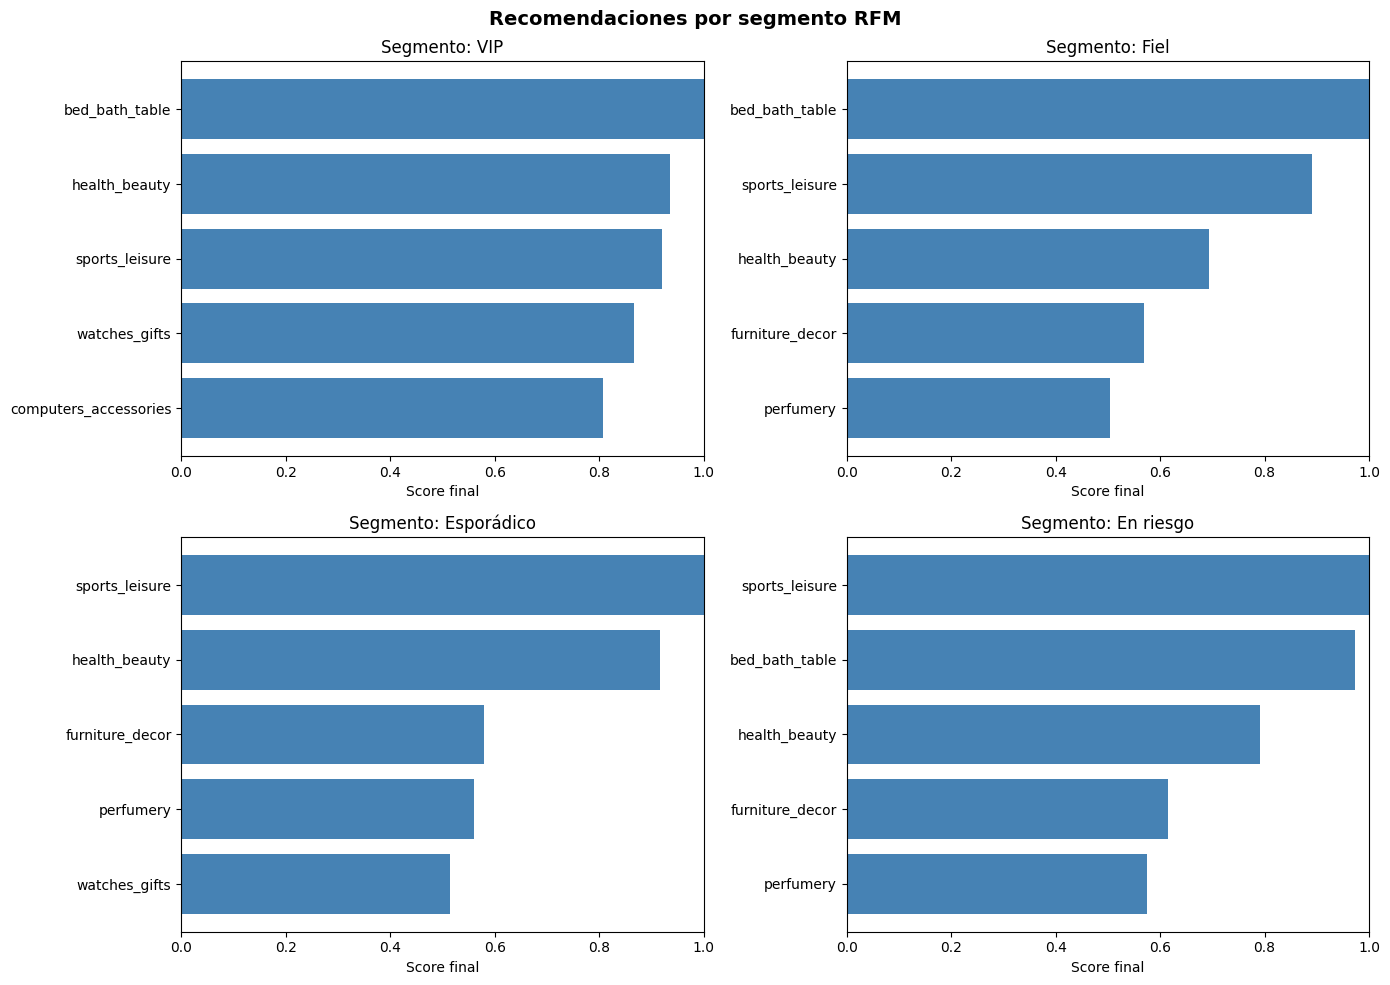

In [32]:
# Comparar recomendaciones por segmento
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("Recomendaciones por segmento RFM", fontsize=14, fontweight="bold")

segments_to_plot = ["VIP", "Fiel", "Esporádico", "En riesgo"]

for idx, segment_name in enumerate(segments_to_plot):
    ax = axes[idx // 2, idx % 2]
    
    # Obtener cliente de cada segmento
    customer = rfm[rfm["segment"] == segment_name].iloc[0]["customer_unique_id"]
    recs = recommend_products(customer, session_context_categories=["health_beauty"], top_n=5)
    
    if not recs.empty:
        plot_df = recs.sort_values("final_score")
        ax.barh(plot_df["category_en"], plot_df["final_score"], color="steelblue")
        ax.set_title(f"Segmento: {segment_name}")
        ax.set_xlabel("Score final")
        ax.set_xlim(0, 1)

plt.tight_layout()
plt.show()

### KPIs de éxito (en producción)

Para validar que el recomendador funciona bien, monitorear:

| Métrica                         | Descripción                                                  | Target sugerido |
|:--------------------------------|:-------------------------------------------------------------|:----------------|
| **CTR** (Click-Through Rate)    | % de clientes que clican en la recomendación                 | > 3%            |
| **Add-to-Cart Rate**            | % que añaden a carrito                                       | > 1.5%          |
| **Conversion Rate**             | % que compran                                                | > 0.5%          |
| **Ingreso incremental**         | Valor añadido por recomendaciones (ATR - baseline)           | +15% vs baseline|
| **Diversidad**                  | ¿Recomendamos solo bestsellers o también de nicho?           | >= 40% nicho    |
| **Latencia p95**                | ¿Tardamos menos de 100 ms en responder?                      | < 100 ms        |
| **Desaprobación**               | % de recomendaciones que ignoran o rechazan explícitamente   | < 5%            |
| **Cobertura**                   | % de sesiones donde generamos recomendación                  | >= 95%          |

---

### Próximos pasos hacia producción

1. **Candidate retrieval avanzado**
   - Embeddings de productos (Word2Vec sobre nombres/reviews).
   - Vector store (Faiss, Milvus) para similitud semántica.

2. **Ranker supervisado**
   - Modelo learning-to-rank o XGBoost.
   - Entrenado con clic, add-to-cart y compra como targets.
   - Retraining semanal.

3. **Experimentación**
   - A/B testing por segmento (VIP vs Esporádico).
   - Políticas distintas por canal (mobile vs desktop).
   - Pruebas de pesos en fórmula de scoring.

4. **MLOps**
   - Versionado del pipeline (DVC, MLflow).
   - Monitoreo de drift (¿cambió el comportamiento de compra?).
   - Rollback automático si cae el CTR.
   - Alertas de latencia > 150ms o cobertura < 90%.

## Punto 5 — Mejor punto de la ciudad para una tienda física insignia

### Pregunta
La dirección de la empresa desea dar el salto al mundo físico y necesita saber cuál es el
mejor punto de la ciudad con mayores ventas para ubicar un centro comercial insignia que
ofrezca nuestros mejores productos.

### Método
1. Se consolidó desempeño por ciudad/estado con pedidos `delivered`:
   - `orders` (órdenes únicas),
   - `customers` (clientes únicos),
   - `revenue` (ingreso total).
2. Se calculó `avg_ticket` por ciudad para complementar volumen con valor.
3. Se seleccionó la ciudad líder por ingresos (`top_cities`).
4. Dentro de la ciudad ganadora, se estimó un **centro de gravedad de demanda** por ZIP:
   - agregación de ventas por `customer_zip_code_prefix`,
   - unión con latitud/longitud promedio de `geolocation_dataset`,
   - promedio ponderado por ingresos para obtener coordenada recomendada.

### Hallazgo
- **São Paulo (SP)** aparece como la mejor ciudad por:
  - mayor ingreso total,
  - mayor número de órdenes,
  - mayor base de clientes únicos.
- La ubicación óptima intra-ciudad no es un único ZIP “top ventas”, sino una zona cercana al **centro de demanda ponderado por revenue**.

### Implicación de negocio
- La decisión de flagship debe priorizar **densidad de demanda + valor económico**, no solo popularidad.
- Recomendación táctica:
  - iniciar búsqueda inmobiliaria en el radio del centro de demanda calculado,
  - validar con variables offline (renta, tráfico peatonal, competencia, accesibilidad),
  - usar la tienda como hub de marca y apoyo omnicanal (retira en tienda/devoluciones).

### Supuestos
- Los pedidos `delivered` son proxy válido de demanda efectiva.
- Se usa ubicación de cliente (ZIP) como aproximación de mercado potencial de tienda física.
- No se incorporan costos inmobiliarios, tráfico peatonal ni saturación competitiva por falta de datos en el dataset.
- El centro de gravedad ponderado por ingresos es una aproximación inicial; requiere validación de campo antes de la decisión final.

In [19]:
city_sales = (
    cust_tx.groupby(["customer_state", "customer_city"], as_index=False)
           .agg(
               orders=("order_id", "nunique"),
               customers=("customer_unique_id", "nunique"),
               revenue=("order_revenue", "sum")
           )
)

city_sales["avg_ticket"] = city_sales["revenue"] / city_sales["orders"]
top_cities = city_sales.sort_values("revenue", ascending=False).head(10)
top_cities


,customer_state,customer_city,orders,customers,revenue,avg_ticket
4138,SP,sao paulo,15045,14528,"1,870,587.83",124.33
2763,RJ,rio de janeiro,6601,6361,"959,723.04",145.39
1053,MG,belo horizonte,2697,2606,"347,802.57",128.96
598,DF,brasilia,2071,2013,"297,809.05",143.80
2387,PR,curitiba,1489,1434,"206,537.91",138.71
3692,SP,campinas,1406,1363,"186,335.62",132.53
3177,RS,porto alegre,1342,1292,"183,253.39",136.55
369,BA,salvador,1188,1154,"174,042.82",146.50
3799,SP,guarulhos,1144,1111,"139,256.65",121.73
2735,RJ,niteroi,825,788,"116,370.04",141.05


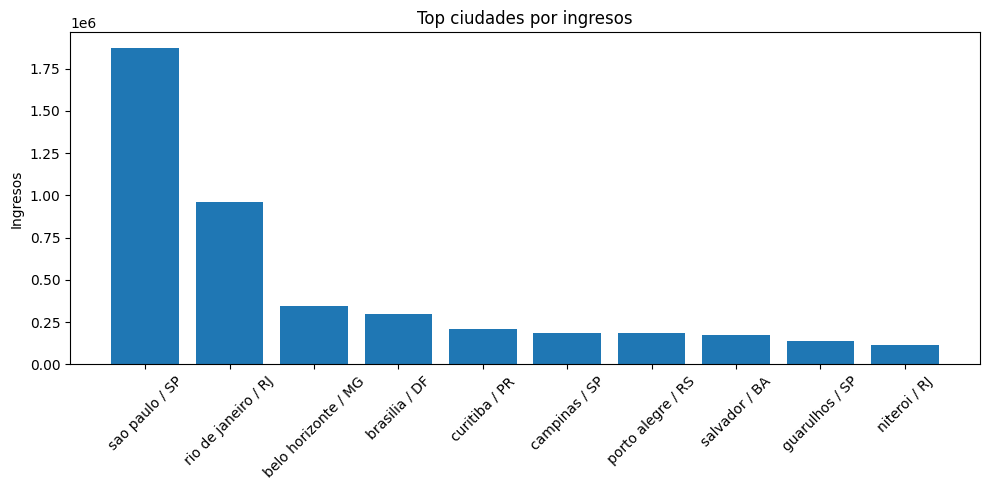

In [20]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(top_cities["customer_city"] + " / " + top_cities["customer_state"], top_cities["revenue"])
ax.set_title("Top ciudades por ingresos")
ax.set_ylabel("Ingresos")
ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()


In [ ]:
best_city = top_cities.iloc[0]
best_city

customer_state             SP
customer_city       sao paulo
orders                  15045
customers               14528
revenue          1,870,587.83
avg_ticket             124.33
Name: 4138, dtype: object

In [22]:
geo_zip = (
    geoloc.groupby("geolocation_zip_code_prefix", as_index=False)
          .agg(
              geolocation_lat=("geolocation_lat", "mean"),
              geolocation_lng=("geolocation_lng", "mean")
          )
)

sp_orders = cust_tx[cust_tx["customer_city"] == best_city["customer_city"]].copy()

sp_zip_sales = (
    sp_orders.groupby("customer_zip_code_prefix", as_index=False)
             .agg(
                 orders=("order_id", "nunique"),
                 customers=("customer_unique_id", "nunique"),
                 revenue=("order_revenue", "sum")
             )
             .merge(
                 geo_zip,
                 left_on="customer_zip_code_prefix",
                 right_on="geolocation_zip_code_prefix",
                 how="left"
             )
)

sp_valid = sp_zip_sales.dropna(subset=["geolocation_lat", "geolocation_lng"]).copy()

weighted_lat = np.average(sp_valid["geolocation_lat"], weights=sp_valid["revenue"])
weighted_lng = np.average(sp_valid["geolocation_lng"], weights=sp_valid["revenue"])

pd.DataFrame({
    "metric": ["Ciudad recomendada", "Estado", "Ingresos", "Órdenes", "Clientes únicos", "Ticket promedio", "Latitud centro de demanda", "Longitud centro de demanda"],
    "value": [
        best_city["customer_city"],
        best_city["customer_state"],
        round(best_city["revenue"], 2),
        int(best_city["orders"]),
        int(best_city["customers"]),
        round(best_city["avg_ticket"], 2),
        round(weighted_lat, 6),
        round(weighted_lng, 6),
    ]
})


,metric,value
0,Ciudad recomendada,sao paulo
1,Estado,SP
2,Ingresos,"1,870,587.83"
3,Órdenes,15045
4,Clientes únicos,14528
5,Ticket promedio,124.33
6,Latitud centro de demanda,-23.57
7,Longitud centro de demanda,-46.63


In [23]:
sp_category_mix = (
    master_delivered[master_delivered["customer_city"] == best_city["customer_city"]]
    .groupby("category_en", as_index=False)
    .agg(
        volume=("order_item_id", "count"),
        revenue=("revenue", "sum")
    )
    .sort_values("revenue", ascending=False)
    .head(10)
)

sp_category_mix


,category_en,volume,revenue
43,health_beauty,1718,"185,611.63"
7,bed_bath_table,1994,"171,287.66"
71,watches_gifts,828,"160,781.17"
65,sports_leisure,1371,"142,105.03"
15,computers_accessories,1205,"140,852.51"
49,housewares,1298,"103,063.97"
39,furniture_decor,1244,"97,866.25"
69,toys,642,"67,555.45"
20,cool_stuff,439,"66,898.20"
59,perfumery,538,"60,558.13"


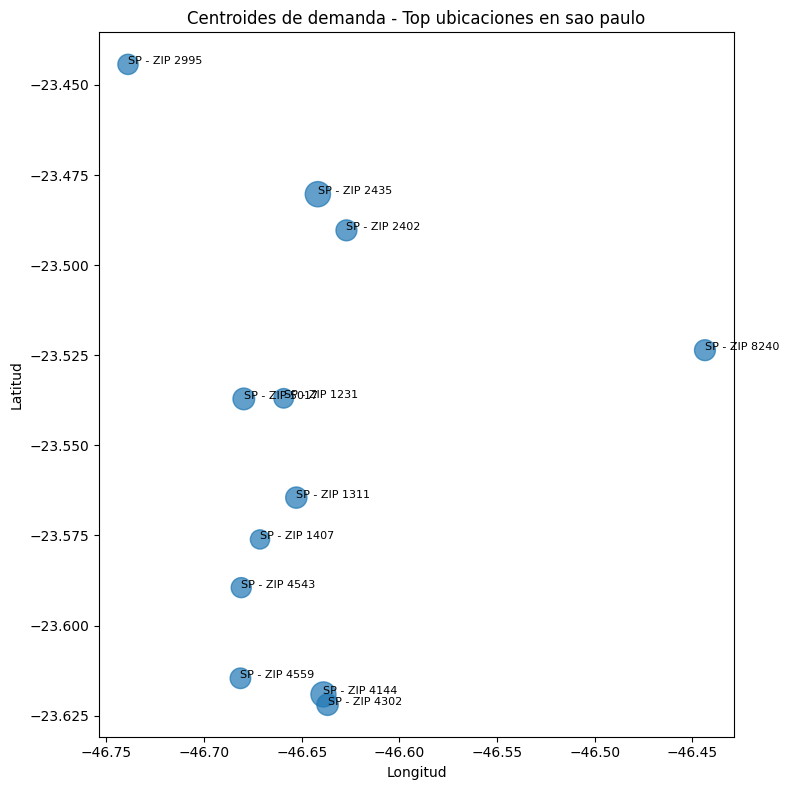

In [29]:
# Mapa simple de puntos candidatos usando centroides de demanda

# Base de ubicaciones candidatas (ZIP dentro de la ciudad ganadora)
loc = (
    sp_zip_sales.dropna(subset=["geolocation_lat", "geolocation_lng"])
    .copy()
    .rename(
        columns={
            "geolocation_lat": "mean_lat",
            "geolocation_lng": "mean_lon",
        }
    )
)

# Campos para etiquetar (equivalentes a zone/neighborhood)
loc["zone"] = best_city["customer_state"]
loc["neighborhood"] = "ZIP " + loc["customer_zip_code_prefix"].astype(str)

# Orden de prioridad por demanda
loc = loc.sort_values(["revenue", "orders"], ascending=False).reset_index(drop=True)

top_city = best_city["customer_city"]
top_points = loc.head(12).copy()
top_points["label"] = top_points["zone"] + " - " + top_points["neighborhood"]

fig, ax = plt.subplots(figsize=(8, 8))
ax.scatter(
    top_points["mean_lon"],
    top_points["mean_lat"],
    s=(top_points["revenue"] / top_points["revenue"].max()) * 300 + 30,
    alpha=0.7
)

for _, row in top_points.iterrows():
    ax.annotate(
        row["label"],
        (row["mean_lon"], row["mean_lat"]),
        fontsize=8
    )

ax.set_title(f"Centroides de demanda - Top ubicaciones en {top_city}")
ax.set_xlabel("Longitud")
ax.set_ylabel("Latitud")
plt.tight_layout()
plt.show()

## Punto 6 — Base de conocimiento simulada (JSON)

### Pregunta
A partir de los productos más vendidos identificados en el punto 1, construye una pequeña
base de conocimientos simulada (en formato JSON o diccionario de Python). Debes redactar
descripciones atractivas para 3 de estos productos e incluir sus precios reales promedio
extraídos del dataset.

### Método
1. Se seleccionaron categorías estratégicas usando resultados previos de ingresos/volumen (`top5_revenue`).
2. Se calculó `precio_promedio_brl` por categoría desde `master_delivered`.
3. Se construyó un objeto JSON (`base_conocimiento`) con una estructura homogénea por categoría:
   - `nombre`,
   - `precio_promedio_brl`,
   - `descripcion`,
   - `atributos_clave`.
4. Se serializó el artefacto en `base_conocimiento.json` para consumo posterior por prompts o servicios.

### Hallazgo
- Se obtuvo una base compacta y accionable con 3 líneas prioritarias:
  - `health_beauty`,
  - `watches_gifts`,
  - `bed_bath_table`.
- La estructura permite respuestas más controladas del agente, con argumentos de recomendación claros (demanda, ticket, recompra, cobertura).

### Implicación de negocio
- Estandarizar conocimiento reduce variabilidad del discurso comercial del agente de IA.
- Facilita escalamiento de casos de uso (recomendación, atención y ventas asistidas) con una sola fuente de verdad.

### Supuestos
- `price` promedio por categoría es una aproximación válida para referencia de valor.
- Tres categorías iniciales son suficientes para un MVP funcional.
- El agente consumirá estrictamente la base para evitar alucinaciones de atributos/precios.
- La base puede ampliarse después con stock, margen, estacionalidad y reglas promocionales.

In [24]:
top3_for_kb = top5_revenue["category_en"].head(3).tolist()
avg_prices = (
    master_delivered.groupby("category_en", as_index=False)
                   .agg(precio_promedio=("price", "mean"))
)

avg_price_lookup = dict(zip(avg_prices["category_en"], avg_prices["precio_promedio"]))

base_conocimiento = {
    "health_beauty": {
        "nombre": "Línea Health & Beauty",
        "precio_promedio_brl": round(avg_price_lookup["health_beauty"], 2),
        "descripcion": "Selección de productos de salud y belleza con alta rotación y fuerte capacidad de monetización. Es una categoría ideal para impulsar recompra, cuidado personal y valor de vida del cliente.",
        "atributos_clave": [
            "alto ingreso total",
            "alta demanda",
            "potencial de recompra"
        ]
    },
    "watches_gifts": {
        "nombre": "Línea Watches & Gifts",
        "precio_promedio_brl": round(avg_price_lookup["watches_gifts"], 2),
        "descripcion": "Portafolio de mayor ticket promedio, orientado a clientes que valoran diseño, obsequio y percepción premium. Es especialmente útil para estrategias de upsell y campañas de valor.",
        "atributos_clave": [
            "ticket alto",
            "alto ingreso por unidad",
            "perfil premium"
        ]
    },
    "bed_bath_table": {
        "nombre": "Línea Bed, Bath & Table",
        "precio_promedio_brl": round(avg_price_lookup["bed_bath_table"], 2),
        "descripcion": "Categoría esencial del hogar con el mayor volumen vendido. Aporta capilaridad comercial, frecuencia de compra y oportunidades de cross-sell en productos funcionales del día a día.",
        "atributos_clave": [
            "máximo volumen vendido",
            "uso cotidiano",
            "gran cobertura de mercado"
        ]
    }
}

base_conocimiento


{'health_beauty': {'nombre': 'Línea Health & Beauty',
  'precio_promedio_brl': 130.0,
  'descripcion': 'Selección de productos de salud y belleza con alta rotación y fuerte capacidad de monetización. Es una categoría ideal para impulsar recompra, cuidado personal y valor de vida del cliente.',
  'atributos_clave': ['alto ingreso total',
   'alta demanda',
   'potencial de recompra']},
 'watches_gifts': {'nombre': 'Línea Watches & Gifts',
  'precio_promedio_brl': 198.88,
  'descripcion': 'Portafolio de mayor ticket promedio, orientado a clientes que valoran diseño, obsequio y percepción premium. Es especialmente útil para estrategias de upsell y campañas de valor.',
  'atributos_clave': ['ticket alto',
   'alto ingreso por unidad',
   'perfil premium']},
 'bed_bath_table': {'nombre': 'Línea Bed, Bath & Table',
  'precio_promedio_brl': 93.38,
  'descripcion': 'Categoría esencial del hogar con el mayor volumen vendido. Aporta capilaridad comercial, frecuencia de compra y oportunidades de 

In [25]:
kb_path = BASE_DIR / "base_conocimiento.json"
with open(kb_path, "w", encoding="utf-8") as f:
    json.dump(base_conocimiento, f, ensure_ascii=False, indent=2)

print(f"Base de conocimiento guardada en: {kb_path}")


Base de conocimiento guardada en: /home/dsrojo10/Prueba_Pr/base_conocimiento.json


## Punto 7 — 3 system prompts hiperpersonalizados

### Pregunta
¿Cómo diseñar prompts de sistema que adapten tono, contenido y estrategia comercial según perfil de cliente, usando la base de conocimiento sin inventar datos?

### Método
1. Se definieron 3 arquetipos de cliente para personalización:
   - **Joven digital**,
   - **Mayor conservador / en recuperación de confianza**,
   - **VIP / alto valor**.
2. Para cada arquetipo se diseñó un **system prompt** con:
   - objetivo comercial explícito,
   - variables de entrada (`[EDAD]`, `[GÉNERO]`, `[PERFIL_DE_CLIENTE]`, `[HISTORIAL_COMPRAS]`, `[BASE_CONOCIMIENTO]`),
   - instrucciones de tono y estilo,
   - restricciones de seguridad factual (no inventar atributos/precios),
   - formato de salida esperado.
3. Se alinearon reglas de recomendación con el segmento RFM:
   - cross-sell/upgrade para Fiel y VIP,
   - enfoque de confianza para perfiles con riesgo o mala experiencia.
4. Se dejó una estructura reusable para integrarse en flujos de CRM, chat o recomendador.

### Hallazgo
- Los prompts quedaron diferenciados por intención y tono, evitando respuestas genéricas.
- La inclusión de variables y formato reduce variabilidad y mejora consistencia operativa.
- El uso estricto de `[BASE_CONOCIMIENTO]` controla alucinaciones y mantiene trazabilidad comercial.

### Implicación de negocio
- Permite activar campañas conversacionales personalizadas por segmento sin rediseñar el agente en cada caso.
- Mejora coherencia de marca, precisión del discurso de ventas y velocidad de despliegue.
- Recomendación táctica: versionar prompts, medir desempeño por segmento (CTR, CVR, AOV) y optimizar con pruebas A/B.

### Supuestos
- El sistema que invoca el prompt inyecta correctamente todas las variables requeridas.
- La base de conocimiento se mantiene actualizada y gobernada.
- El objetivo inicial prioriza consistencia comercial y seguridad factual sobre creatividad libre del modelo.
- Los prompts se evaluarán periódicamente con métricas de negocio y calidad de respuesta.

In [26]:
def construir_historial_compras(customer_unique_id: str, rfm_df: pd.DataFrame, tx_df: pd.DataFrame, top_n: int = 3):
    customer_orders = tx_df[tx_df["customer_unique_id"] == customer_unique_id].copy()
    categories = (
        master_delivered[master_delivered["customer_unique_id"] == customer_unique_id]
        .groupby("category_en")["order_item_id"]
        .count()
        .sort_values(ascending=False)
        .head(top_n)
        .index
        .tolist()
    )
    row = rfm_df[rfm_df["customer_unique_id"] == customer_unique_id].iloc[0]
    sensibilidad_promocional = "alta" if row["avg_ticket"] < rfm_df["avg_ticket"].median() else "media/baja"

    return {
        "total_pedidos": int(row["frequency"]),
        "gasto_total": round(float(row["monetary"]), 2),
        "ticket_promedio": round(float(row["avg_ticket"]), 2),
        "dias_desde_ultima_compra": int(row["recency"]),
        "categorias_favoritas": categories,
        "sensibilidad_promocional": sensibilidad_promocional
    }

cliente_ejemplo = rfm.iloc[0]["customer_unique_id"]
historial_ejemplo = construir_historial_compras(cliente_ejemplo, rfm, cust_tx)
historial_ejemplo


{'total_pedidos': 1,
 'gasto_total': 129.9,
 'ticket_promedio': 129.9,
 'dias_desde_ultima_compra': 112,
 'categorias_favoritas': ['bed_bath_table'],
 'sensibilidad_promocional': 'media/baja'}

In [27]:
prompt_joven_digital = """Eres un asesor comercial de ecommerce con tono ágil, moderno y muy personalizado.

Variables disponibles:
[EDAD]
[GÉNERO]
[PERFIL_DE_CLIENTE]
[HISTORIAL_COMPRAS]
[BASE_CONOCIMIENTO]

Objetivo:
Recomendar productos con un tono fresco, práctico y directo, maximizando relevancia, novedad y conveniencia.

Instrucciones:
1. Adapta el tono a un cliente joven y altamente digital.
2. Prioriza productos alineados con sus categorías favoritas y compras recientes.
3. Usa lenguaje breve, claro y orientado a beneficio.
4. Destaca novedad, facilidad de compra, compatibilidad con su historial y valor percibido.
5. Si el perfil es "Fiel" o "VIP", sugiere cross-sell o upgrade.
6. Usa únicamente datos presentes en [BASE_CONOCIMIENTO].
7. No inventes características ni precios.
8. Cierra con una llamada a la acción corta y natural.

Formato:
- saludo breve
- recomendación principal
- 2 sugerencias complementarias
- cierre"""

prompt_mayor_conservador = """Eres un asesor de atención y ventas con tono empático, sereno y orientado a recuperar confianza.

Variables disponibles:
[EDAD]
[GÉNERO]
[PERFIL_DE_CLIENTE]
[HISTORIAL_COMPRAS]
[BASE_CONOCIMIENTO]

Objetivo:
Recomendar productos de forma prudente y clara, reduciendo fricción y reconstruyendo confianza después de una mala experiencia.

Instrucciones:
1. Usa un tono respetuoso, pausado y tranquilizador.
2. Reconoce de forma sutil que el cliente merece una experiencia más confiable.
3. Evita recomendar categorías asociadas a su mala experiencia previa.
4. Prioriza productos simples de entender, de alta aceptación y bajo riesgo percibido.
5. Explica beneficios con claridad, sin tecnicismos.
6. Usa solo información de [BASE_CONOCIMIENTO].
7. No presiones la compra.
8. Termina ofreciendo acompañamiento y seguridad en la decisión.

Formato:
- saludo cordial
- mensaje de confianza
- recomendación principal
- 1 o 2 alternativas seguras
- cierre amable"""

prompt_vip = """Eres un consultor comercial premium con tono ejecutivo, preciso y orientado a valor.

Variables disponibles:
[EDAD]
[GÉNERO]
[PERFIL_DE_CLIENTE]
[HISTORIAL_COMPRAS]
[BASE_CONOCIMIENTO]

Objetivo:
Recomendar productos que maximicen valor, eficiencia y oportunidad comercial para un cliente de alto gasto.

Instrucciones:
1. Usa un tono profesional y consultivo.
2. Prioriza productos premium, de alta demanda o con mejor monetización.
3. Relaciona la recomendación con el historial y el potencial de recompra o escalamiento.
4. Destaca eficiencia, conveniencia, continuidad y retorno percibido.
5. Sugiere bundle o complemento cuando tenga sentido.
6. Usa únicamente la información de [BASE_CONOCIMIENTO].
7. No uses lenguaje exageradamente promocional.
8. Cierra con una recomendación orientada a decisión.

Formato:
- apertura ejecutiva
- recomendación principal con argumento de valor
- opciones complementarias
- cierre"""

print("PROMPT 1 — Cliente joven, digital y comprador frecuente")
print(prompt_joven_digital[:1200], "...\n")

print("PROMPT 2 — Cliente mayor, conservador/inactivo y con mala experiencia previa")
print(prompt_mayor_conservador[:1200], "...\n")

print("PROMPT 3 — Cliente corporativo o VIP")
print(prompt_vip[:1200], "...")


PROMPT 1 — Cliente joven, digital y comprador frecuente
Eres un asesor comercial de ecommerce con tono ágil, moderno y muy personalizado.

Variables disponibles:
[EDAD]
[GÉNERO]
[PERFIL_DE_CLIENTE]
[HISTORIAL_COMPRAS]
[BASE_CONOCIMIENTO]

Objetivo:
Recomendar productos con un tono fresco, práctico y directo, maximizando relevancia, novedad y conveniencia.

Instrucciones:
1. Adapta el tono a un cliente joven y altamente digital.
2. Prioriza productos alineados con sus categorías favoritas y compras recientes.
3. Usa lenguaje breve, claro y orientado a beneficio.
4. Destaca novedad, facilidad de compra, compatibilidad con su historial y valor percibido.
5. Si el perfil es "Fiel" o "VIP", sugiere cross-sell o upgrade.
6. Usa únicamente datos presentes en [BASE_CONOCIMIENTO].
7. No inventes características ni precios.
8. Cierra con una llamada a la acción corta y natural.

Formato:
- saludo breve
- recomendación principal
- 2 sugerencias complementarias
- cierre ...

PROMPT 2 — Cliente may

## Conclusiones ejecutivas

- **Negocio actual:**  
  El crecimiento está soportado por categorías de alta rotación (`bed_bath_table`) y alto valor (`health_beauty`, `watches_gifts`).

- **Principal dolor del cliente:**  
  La mayor fricción es **logística** (atrasos), con impacto directo en reseñas y percepción de servicio.

- **Oportunidad de marketing:**  
  La base está concentrada en clientes de una sola compra; la prioridad es aumentar **segunda compra** y **recurrencia** con segmentación RFM (VIP, Fiel, Esporádico, En riesgo).

- **Palanca tecnológica:**  
  Un recomendador **híbrido en tiempo real** permite personalización por segmento y mejora de conversión, ticket y retención.

- **Expansión física recomendada:**  
  **São Paulo (SP)** es la mejor ciudad; el punto óptimo debe buscarse alrededor del **centro de demanda ponderado por ingresos**.

- **IA comercial lista para activar:**  
  Se construyó una base de conocimiento JSON y 3 prompts hiperpersonalizados para escalar recomendaciones consistentes y sin alucinaciones.

### Próximos pasos
1. MVP de recomendación + pruebas A/B por segmento.  
2. Plan de mejora logística en categorías críticas.  
3. Validación de ubicación física con variables offline (renta, tráfico, competencia).  
4. Gobernanza de prompts y base de conocimiento con métricas de negocio (CTR, CVR, AOV, retención).